## 1. Import Libraries

In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from itertools import combinations
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

SEASON_ORDER = ["Kharif", "Rabi", "Zaid"]

sns.set_theme(style="whitegrid", context="notebook")
print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the Dataset

In [3]:
df = pd.read_csv("seasonal_agriculture_performance_dataset (3).csv")
print("Shape:", df.shape)
df.head()
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Shape: (4000, 28)
Rows: 4,000
Columns: 28


## 3. Understand the Dataset

In [4]:
display(df.head())
print("\nColumn names:")
print(df.columns.tolist())

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30



Column names:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [5]:
print("Data types:")
display(df.dtypes.to_frame("dtype"))

print("\nDataset shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())
print("Unique Farm_ID values:", df["Farm_ID"].nunique())


Data types:


,dtype
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64



Dataset shape: (4000, 28)
Duplicate rows: 0
Unique Farm_ID values: 4000


## 4. Data Quality Assessment

In [6]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_%": missing_pct
})
display(missing_report[missing_report["Missing_Count"] > 0])

,Missing_Count,Missing_%
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80


In [7]:
numeric_cols = df.select_dtypes(include=np.number).columns

negative_counts = (df[numeric_cols] < 0).sum().sort_values(ascending=False)
print("Negative values in numeric columns:")
display(negative_counts[negative_counts > 0])

print("Category values:")
for col in ["State", "District", "Crop", "Season", "Irrigation_Method"]:
    print(f"\n{col}: {sorted(df[col].dropna().unique().tolist())}")

Negative values in numeric columns:


Profit_INR    1966
dtype: int64

Category values:

State: ['Andhra Pradesh', 'Gujarat', 'Karnataka', 'Madhya Pradesh', 'Maharashtra', 'Punjab', 'Tamil Nadu', 'Telangana']

District: ['Erode', 'Guntur', 'Indore', 'Krishna', 'Ludhiana', 'Nalgonda', 'Nashik', 'Raichur', 'Rajkot', 'Warangal']

Crop: ['Chilli', 'Cotton', 'Groundnut', 'Maize', 'Pulses', 'Rice', 'Sugarcane', 'Wheat']

Season: ['Kharif', 'Rabi', 'Zaid']

Irrigation_Method: ['Drip', 'Flood', 'Rainfed', 'Sprinkler']


In [8]:
profit_check = (df["Revenue_INR"] - df["Total_Cost_INR"] - df["Profit_INR"]).abs()
production_expected = df["Yield_Tonnes_Ha"] * df["Farm_Area_Hectares"]
production_diff = (df["Production_Tonnes"] - production_expected).abs()

print("Maximum absolute Profit calculation difference:", profit_check.max())
print("Median absolute Production calculation difference:", production_diff.median())
print("Maximum absolute Production calculation difference:", production_diff.max())

Maximum absolute Profit calculation difference: 0
Median absolute Production calculation difference: 0.0024999999999977263
Maximum absolute Production calculation difference: 0.005000000000002558


In [9]:
profit_check = (df["Revenue_INR"] - df["Total_Cost_INR"] - df["Profit_INR"]).abs()
production_expected = df["Yield_Tonnes_Ha"] * df["Farm_Area_Hectares"]
production_diff = (df["Production_Tonnes"] - production_expected).abs()

print("Maximum absolute Profit calculation difference:", profit_check.max())
print("Median absolute Production calculation difference:", production_diff.median())
print("Maximum absolute Production calculation difference:", production_diff.max())

Maximum absolute Profit calculation difference: 0
Median absolute Production calculation difference: 0.0024999999999977263
Maximum absolute Production calculation difference: 0.005000000000002558


## 5. Data Cleaning and Preparation

In [10]:
df_clean = df.copy()

# Remove exact duplicates
df_clean = df_clean.drop_duplicates().copy()

# Standardize text fields
text_cols = ["State", "District", "Crop", "Season", "Irrigation_Method"]
for col in text_cols:
    df_clean[col] = df_clean[col].astype("string").str.strip()

# Validate season categories
df_clean = df_clean[df_clean["Season"].isin(SEASON_ORDER)].copy()

# Season-based imputation for environmental variables
for col in ["Rainfall_mm", "Soil_Moisture_pct"]:
    df_clean[col] = df_clean.groupby("Season")[col].transform(
        lambda s: s.fillna(s.median())
    )

# Analytical features
df_clean["Profit_Margin_pct"] = np.where(
    df_clean["Revenue_INR"] > 0,
    df_clean["Profit_INR"] / df_clean["Revenue_INR"] * 100,
    np.nan
)
df_clean["Loss_Flag"] = (df_clean["Profit_INR"] < 0).astype(int)

print("Cleaned shape:", df_clean.shape)
print("Remaining missing values:")
display(df_clean.isna().sum()[df_clean.isna().sum() > 0])

Cleaned shape: (4000, 30)
Remaining missing values:


Yield_Tonnes_Ha    32
dtype: int64

In [11]:
print("\nColumn names:")
print(df_clean.columns.tolist())


Column names:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct', 'Profit_Margin_pct', 'Loss_Flag']


## 6. Descriptive Statistics

In [12]:
display(df_clean.describe().T)

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,"4,000.00",7.89,4.22,0.50,4.26,7.89,11.65,15.00
Rainfall_mm,"4,000.00",600.71,288.43,80.00,370.43,581.00,836.12,"1,395.20"
Avg_Temperature_C,"4,000.00",26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,"4,000.00",63.21,11.96,25.00,54.77,63.00,71.90,95.00
Sunlight_Hours_Day,"4,000.00",7.32,1.12,3.50,6.60,7.30,8.10,11.00
Soil_pH,"4,000.00",6.70,0.64,5.20,6.26,6.69,7.14,8.40
Soil_Moisture_pct,"4,000.00",26.50,6.70,8.00,21.70,26.40,31.20,47.00
Nitrogen_kg_ha,"4,000.00",120.25,31.22,40.00,98.50,120.10,141.22,220.00
Phosphorus_kg_ha,"4,000.00",57.78,17.02,15.00,46.20,57.50,69.40,120.00
Potassium_kg_ha,"4,000.00",104.76,27.74,30.00,86.20,105.10,123.60,200.00


## 7. Dataset Composition

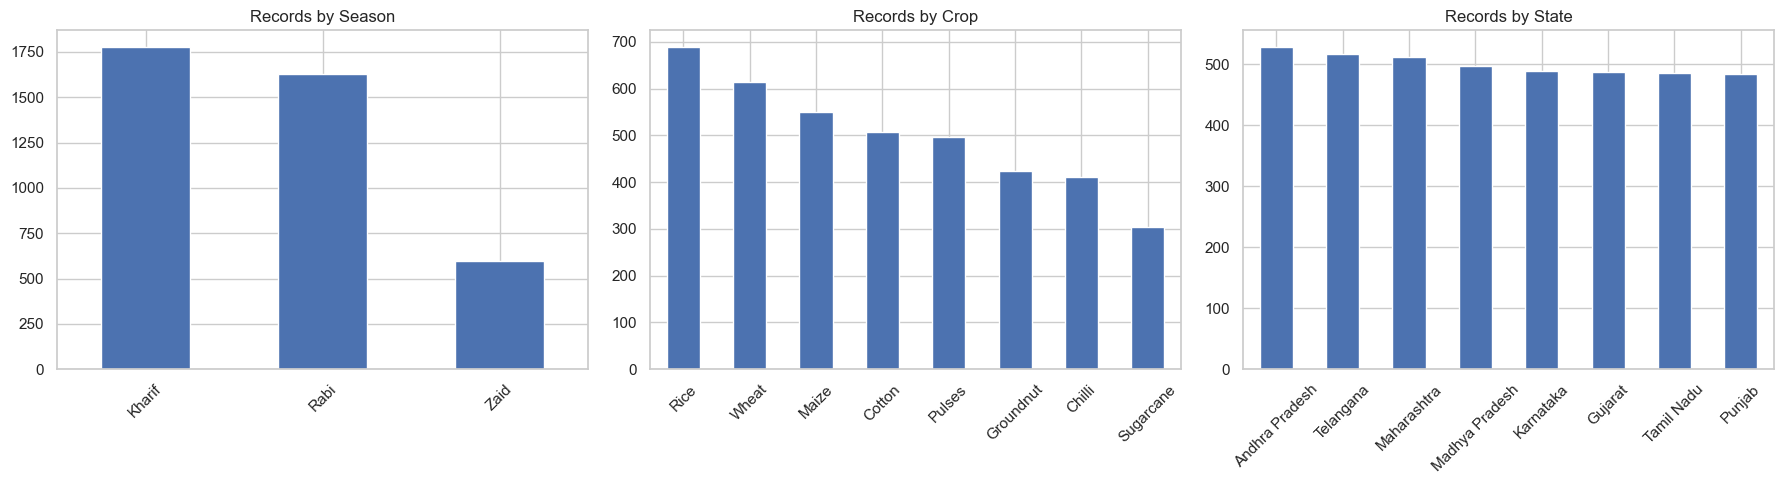

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df_clean["Season"].value_counts().reindex(SEASON_ORDER).plot(
    kind="bar", ax=axes[0], title="Records by Season"
)
df_clean["Crop"].value_counts().sort_values(ascending=False).plot(
    kind="bar", ax=axes[1], title="Records by Crop"
)
df_clean["State"].value_counts().sort_values(ascending=False).plot(
    kind="bar", ax=axes[2], title="Records by State"
)

for ax in axes:
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# 8. Core Seasonal Performance Analysis

In [14]:
season_summary = df_clean.groupby("Season").agg(
    Farms=("Farm_ID", "count"),
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Median_Yield=("Yield_Tonnes_Ha", "median"),
    Avg_Production=("Production_Tonnes", "mean"),
    Avg_Cost=("Total_Cost_INR", "mean"),
    Avg_Revenue=("Revenue_INR", "mean"),
    Avg_Profit=("Profit_INR", "mean"),
    Avg_Profit_Margin=("Profit_Margin_pct", "mean"),
    Avg_Water=("Water_Used_m3", "mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Avg_Risk=("Disease_Pest_Risk_pct", "mean"),
    Loss_Rate=("Loss_Flag", "mean")
).reindex(SEASON_ORDER)

season_summary["Loss_Rate"] *= 100
display(season_summary.round(2))

,Farms,Avg_Yield,Median_Yield,Avg_Production,Avg_Cost,Avg_Revenue,Avg_Profit,Avg_Profit_Margin,Avg_Water,Avg_Water_Efficiency,Avg_Risk,Loss_Rate
Season,,,,,,,,,,,,
Kharif,1779,5.64,1.95,46.31,"531,804.41","710,719.06","178,914.65",-38.64,"6,102.20",5.89,54.47,42.21
Rabi,1627,5.08,1.66,41.49,"513,836.58","601,526.05","87,689.47",-44.27,"5,846.99",5.19,40.48,51.14
Zaid,594,4.67,1.45,38.89,"543,976.73","519,171.90","-24,804.82",-69.35,"6,419.89",4.41,38.22,64.48


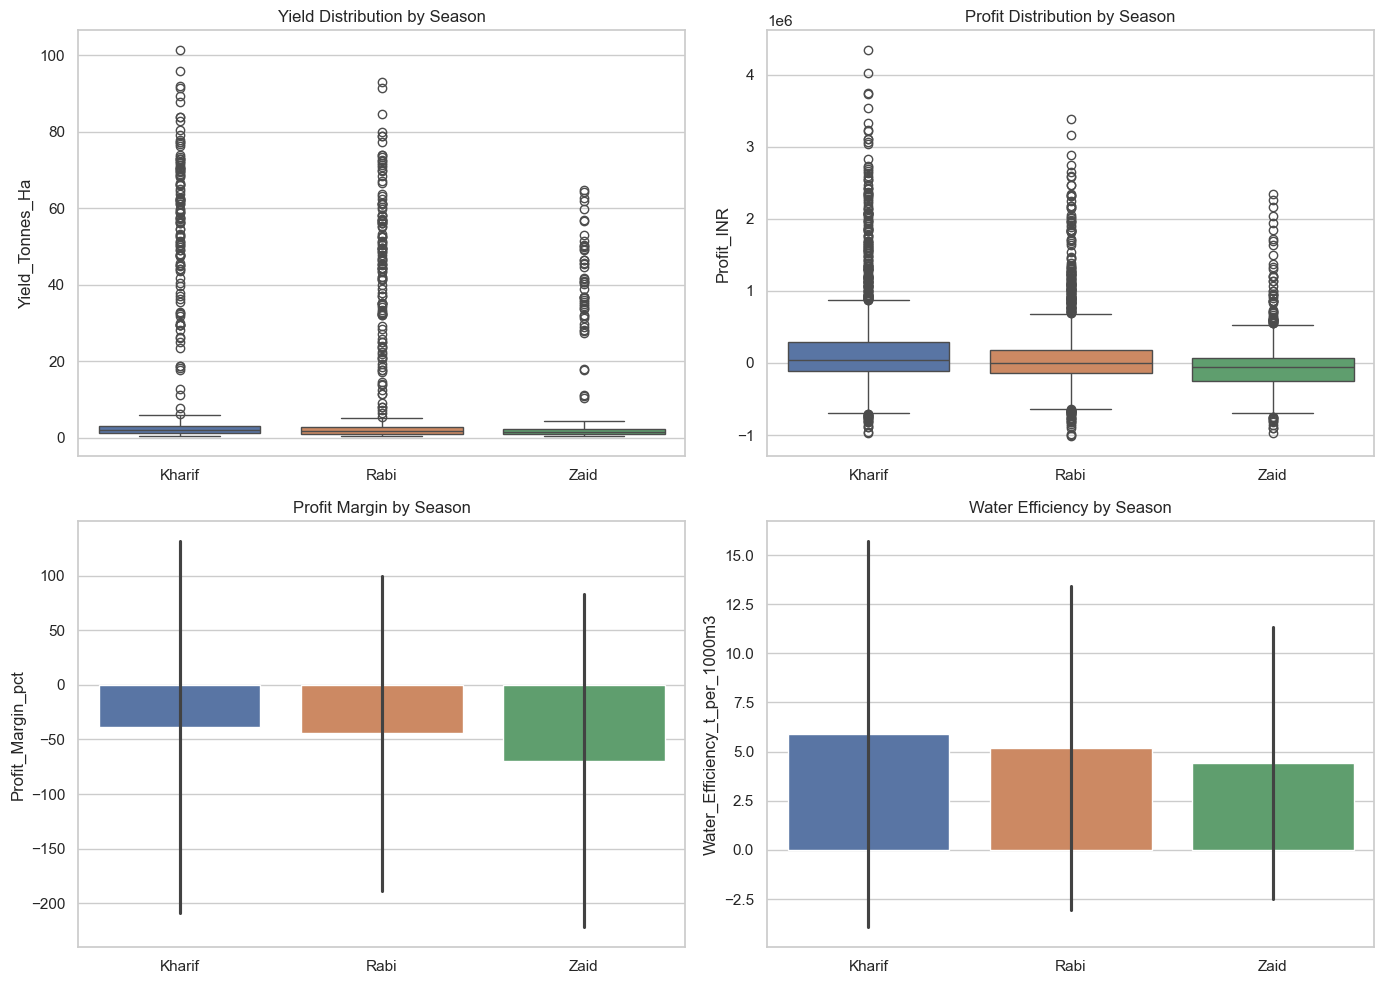

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(
    data=df_clean, x="Season", y="Yield_Tonnes_Ha",
    hue="Season", order=SEASON_ORDER, hue_order=SEASON_ORDER,
    legend=False, ax=axes[0,0]
)
axes[0,0].set_title("Yield Distribution by Season")
axes[0,0].set_xlabel("")

sns.boxplot(
    data=df_clean, x="Season", y="Profit_INR",
    hue="Season", order=SEASON_ORDER, hue_order=SEASON_ORDER,
    legend=False, ax=axes[0,1]
)
axes[0,1].set_title("Profit Distribution by Season")
axes[0,1].set_xlabel("")

sns.barplot(
    data=df_clean, x="Season", y="Profit_Margin_pct",
    hue="Season", order=SEASON_ORDER, hue_order=SEASON_ORDER,
    errorbar="sd", legend=False, ax=axes[1,0]
)
axes[1,0].set_title("Profit Margin by Season")
axes[1,0].set_xlabel("")

sns.barplot(
    data=df_clean, x="Season", y="Water_Efficiency_t_per_1000m3",
    hue="Season", order=SEASON_ORDER, hue_order=SEASON_ORDER,
    errorbar="sd", legend=False, ax=axes[1,1]
)
axes[1,1].set_title("Water Efficiency by Season")
axes[1,1].set_xlabel("")

plt.tight_layout()
plt.show()


# 9. Environmental Conditions and Agricultural Outcomes


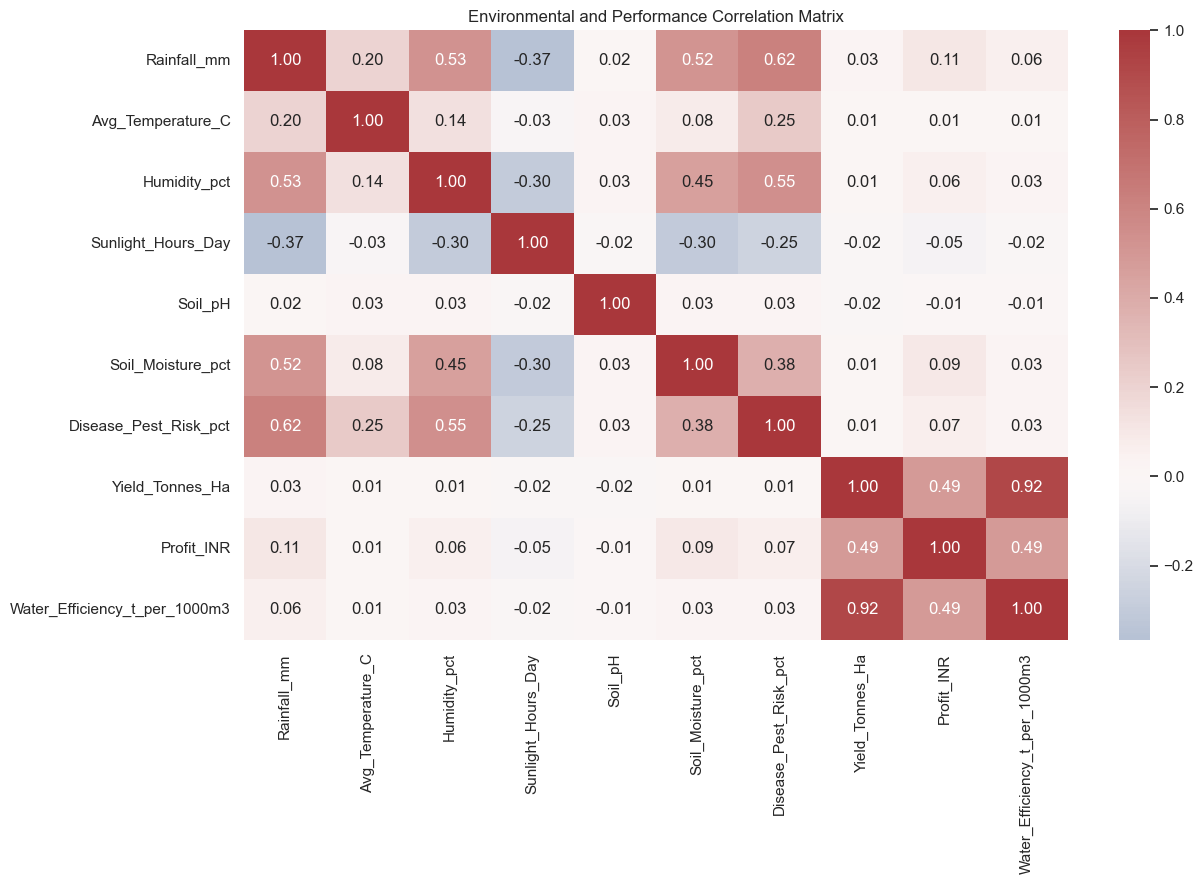

In [16]:
env_cols = [
    "Rainfall_mm", "Avg_Temperature_C", "Humidity_pct",
    "Sunlight_Hours_Day", "Soil_pH", "Soil_Moisture_pct",
    "Disease_Pest_Risk_pct"
]
outcome_cols = [
    "Yield_Tonnes_Ha", "Profit_INR",
    "Water_Efficiency_t_per_1000m3"
]

corr_cols = env_cols + outcome_cols
corr = df_clean[corr_cols].corr()

plt.figure(figsize=(13, 9))
sns.heatmap(corr, annot=True, fmt=".2f", center=0, cmap="vlag")
plt.title("Environmental and Performance Correlation Matrix")
plt.tight_layout()
plt.show()

In [17]:
# Rainfall-Yield association: Pearson and Spearman
overall_pearson = df_clean["Rainfall_mm"].corr(
    df_clean["Yield_Tonnes_Ha"], method="pearson"
)
overall_spearman = df_clean["Rainfall_mm"].corr(
    df_clean["Yield_Tonnes_Ha"], method="spearman"
)

print(f"Overall Pearson correlation : {overall_pearson:.3f}")
print(f"Overall Spearman correlation: {overall_spearman:.3f}")

rainfall_by_season = []
for season in SEASON_ORDER:
    sub = df_clean[df_clean["Season"] == season]
    rainfall_by_season.append({
        "Season": season,
        "Pearson": sub["Rainfall_mm"].corr(sub["Yield_Tonnes_Ha"], method="pearson"),
        "Spearman": sub["Rainfall_mm"].corr(sub["Yield_Tonnes_Ha"], method="spearman")
    })

display(pd.DataFrame(rainfall_by_season).round(3))


Overall Pearson correlation : 0.028
Overall Spearman correlation: 0.131


,Season,Pearson,Spearman
0,Kharif,-0.02,-0.08
1,Rabi,0.04,0.13
2,Zaid,0.05,0.19


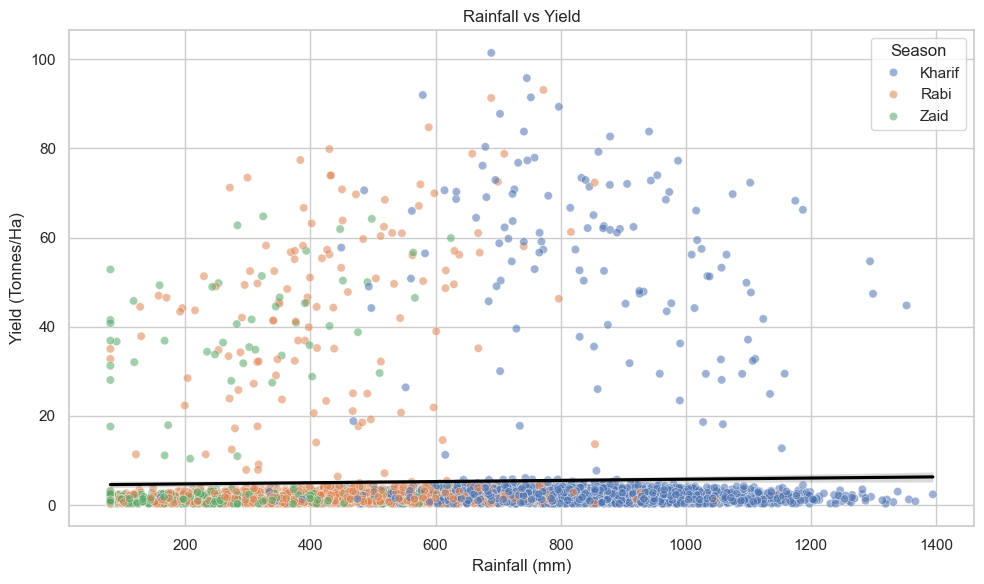

In [18]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_clean, x="Rainfall_mm", y="Yield_Tonnes_Ha",
    hue="Season", hue_order=SEASON_ORDER, alpha=0.55
)
sns.regplot(
    data=df_clean, x="Rainfall_mm", y="Yield_Tonnes_Ha",
    scatter=False, color="black"
)
plt.title("Rainfall vs Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

# 10. Resource Usage and Water Efficiency

In [19]:
resource_summary = df_clean.groupby("Season").agg(
    Fertilizer_kg_ha=("Fertilizer_kg_ha", "mean"),
    Pesticide_Litre_ha=("Pesticide_Litre_ha", "mean"),
    Nitrogen_kg_ha=("Nitrogen_kg_ha", "mean"),
    Phosphorus_kg_ha=("Phosphorus_kg_ha", "mean"),
    Potassium_kg_ha=("Potassium_kg_ha", "mean"),
    Water_Used_m3=("Water_Used_m3", "mean"),
    Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
).reindex(SEASON_ORDER)

display(resource_summary.round(2))

,Fertilizer_kg_ha,Pesticide_Litre_ha,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Water_Used_m3,Water_Efficiency
Season,,,,,,,
Kharif,187.08,5.08,120.02,58.10,105.30,"6,102.20",5.89
Rabi,185.41,5.02,120.40,57.31,103.93,"5,846.99",5.19
Zaid,184.64,5.17,120.53,58.13,105.42,"6,419.89",4.41


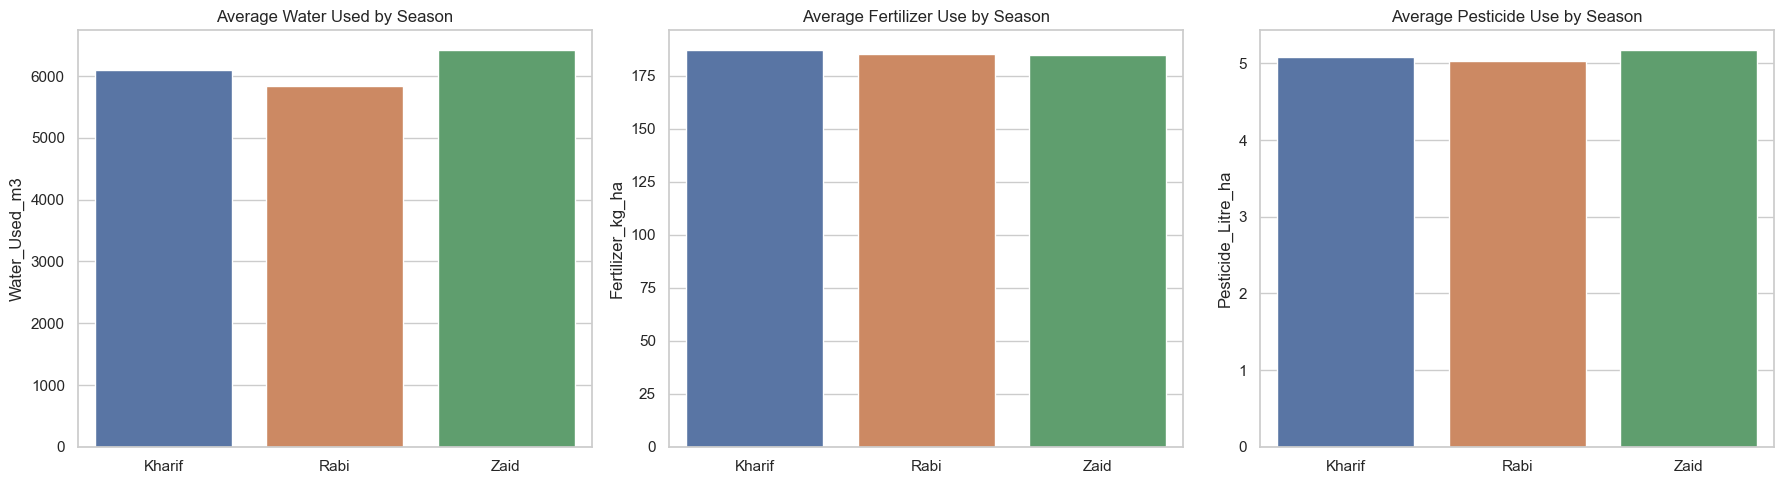

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(
    data=df_clean, x="Season", y="Water_Used_m3",
    hue="Season", order=SEASON_ORDER, hue_order=SEASON_ORDER,
    errorbar=None, legend=False, ax=axes[0]
)
axes[0].set_title("Average Water Used by Season")
axes[0].set_xlabel("")

sns.barplot(
    data=df_clean, x="Season", y="Fertilizer_kg_ha",
    hue="Season", order=SEASON_ORDER, hue_order=SEASON_ORDER,
    errorbar=None, legend=False, ax=axes[1]
)
axes[1].set_title("Average Fertilizer Use by Season")
axes[1].set_xlabel("")

sns.barplot(
    data=df_clean, x="Season", y="Pesticide_Litre_ha",
    hue="Season", order=SEASON_ORDER, hue_order=SEASON_ORDER,
    errorbar=None, legend=False, ax=axes[2]
)
axes[2].set_title("Average Pesticide Use by Season")
axes[2].set_xlabel("")

plt.tight_layout()
plt.show()

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,22.77,33.16,26.03,18.04
Rabi,22.74,32.33,26.92,18.01
Zaid,23.57,32.66,23.57,20.20


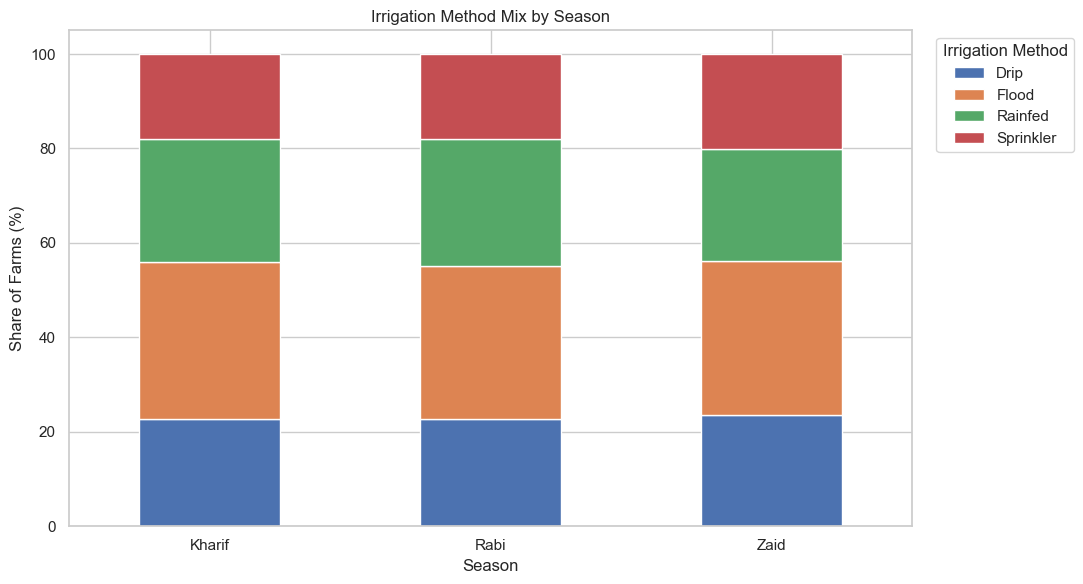

In [21]:
irrigation_summary = pd.crosstab(
    df_clean["Season"], df_clean["Irrigation_Method"],
    normalize="index"
).reindex(SEASON_ORDER) * 100

display(irrigation_summary.round(2))

irrigation_summary.plot(kind="bar", stacked=True, figsize=(11, 6))
plt.title("Irrigation Method Mix by Season")
plt.xlabel("Season")
plt.ylabel("Share of Farms (%)")
plt.xticks(rotation=0)
plt.legend(title="Irrigation Method", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# 11. Crop × Season Analysis

In [22]:
crop_season_yield = pd.pivot_table(
    df_clean,
    index="Crop",
    columns="Season",
    values="Yield_Tonnes_Ha",
    aggfunc="mean"
).reindex(columns=SEASON_ORDER)

display(crop_season_yield.round(2))

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.46,1.18
Cotton,1.37,1.19,0.95
Groundnut,1.48,1.22,1.04
Maize,2.97,2.61,2.30
Pulses,1.04,0.87,0.65
Rice,2.71,2.33,1.90
Sugarcane,53.46,43.94,38.42
Wheat,2.26,2.06,1.75


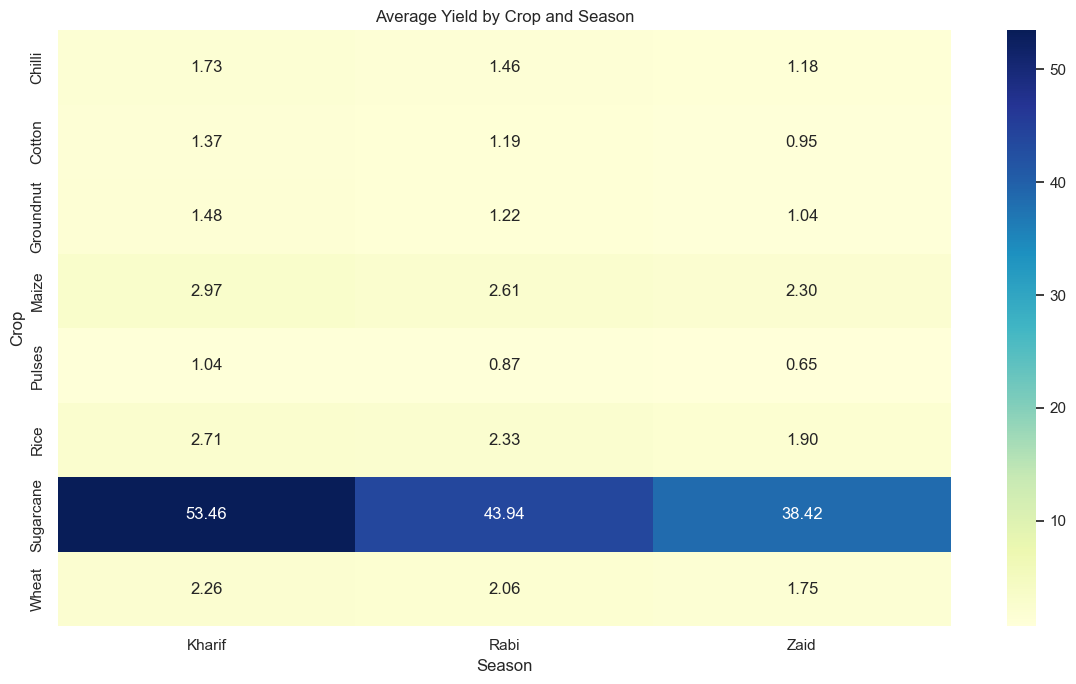

In [23]:
plt.figure(figsize=(12, 7))
sns.heatmap(crop_season_yield, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Average Yield by Crop and Season")
plt.xlabel("Season")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()

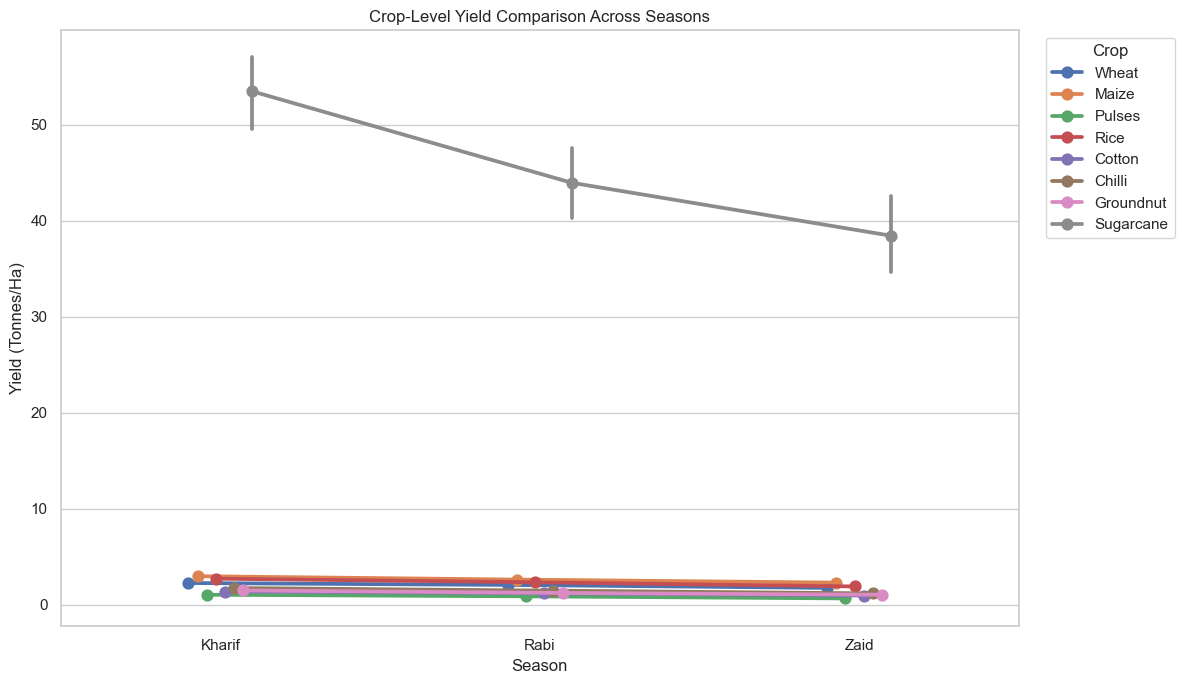

In [24]:
plt.figure(figsize=(12, 7))
sns.pointplot(
    data=df_clean,
    x="Season", y="Yield_Tonnes_Ha", hue="Crop",
    order=SEASON_ORDER, errorbar="ci", dodge=True
)
plt.title("Crop-Level Yield Comparison Across Seasons")
plt.ylabel("Yield (Tonnes/Ha)")
plt.xlabel("Season")
plt.legend(title="Crop", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# 12. State × Season Analysis

In [25]:
state_season_profit = pd.pivot_table(
    df_clean,
    index="State",
    columns="Season",
    values="Profit_INR",
    aggfunc="mean"
).reindex(columns=SEASON_ORDER)

display(state_season_profit.round(0))

Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,"169,316.00","26,316.00","-84,085.00"
Gujarat,"217,051.00","82,846.00","-106,930.00"
Karnataka,"201,226.00","70,953.00","23,311.00"
Madhya Pradesh,"134,242.00","61,576.00",210.00
Maharashtra,"168,801.00","159,582.00","-40,598.00"
Punjab,"133,779.00","169,295.00","62,110.00"
Tamil Nadu,"211,304.00","70,457.00","-15,175.00"
Telangana,"199,668.00","62,825.00","-34,621.00"


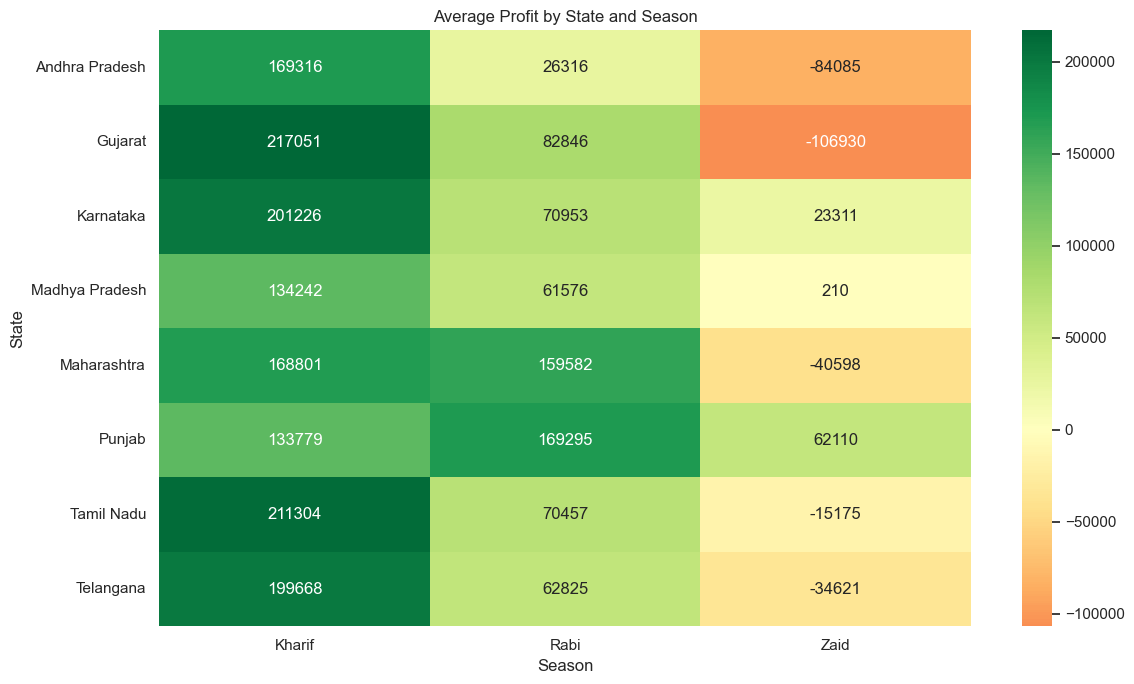

In [26]:
plt.figure(figsize=(12, 7))
sns.heatmap(state_season_profit, annot=True, fmt=".0f", cmap="RdYlGn", center=0)
plt.title("Average Profit by State and Season")
plt.xlabel("Season")
plt.ylabel("State")
plt.tight_layout()
plt.show()

Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,43.30,53.40,70.60
Gujarat,39.80,52.50,71.60
Karnataka,41.10,50.00,58.10
Madhya Pradesh,44.70,54.30,63.50
Maharashtra,44.60,49.50,68.10
Punjab,44.30,48.40,55.80
Tamil Nadu,43.20,54.30,62.00
Telangana,36.80,46.20,65.90


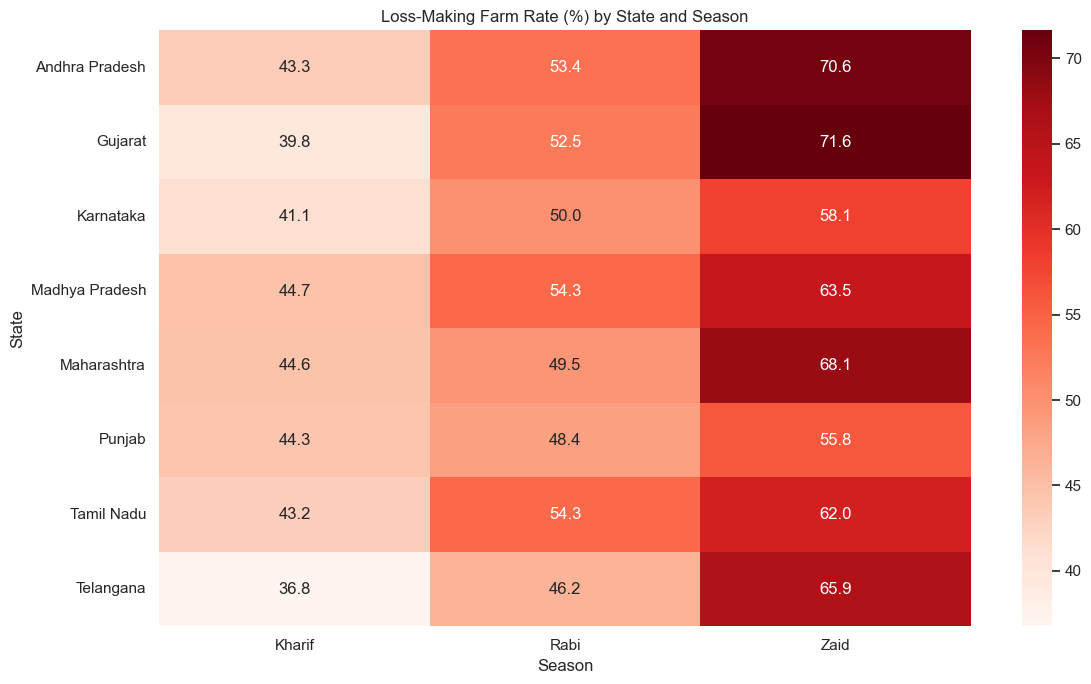

In [27]:
state_season_loss = pd.pivot_table(
    df_clean,
    index="State",
    columns="Season",
    values="Loss_Flag",
    aggfunc="mean"
).reindex(columns=SEASON_ORDER) * 100

display(state_season_loss.round(1))

plt.figure(figsize=(12, 7))
sns.heatmap(state_season_loss, annot=True, fmt=".1f", cmap="Reds")
plt.title("Loss-Making Farm Rate (%) by State and Season")
plt.xlabel("Season")
plt.ylabel("State")
plt.tight_layout()
plt.show()


# 13. Irrigation Method and Seasonal Performance

In [28]:
irrigation_perf = df_clean.groupby(
    ["Season", "Irrigation_Method"]
).agg(
    Farms=("Farm_ID", "count"),
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Avg_Profit=("Profit_INR", "mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Loss_Rate=("Loss_Flag", "mean")
).reset_index()

irrigation_perf["Loss_Rate"] *= 100
display(irrigation_perf.round(2))

,Season,Irrigation_Method,Farms,Avg_Yield,Avg_Profit,Avg_Water_Efficiency,Loss_Rate
0,Kharif,Drip,405,7.26,"317,222.07",6.80,34.07
1,Kharif,Flood,590,5.00,"133,373.83",3.64,46.27
2,Kharif,Rainfed,463,5.72,"158,974.13",8.85,44.28
3,Kharif,Sprinkler,321,4.67,"116,880.49",4.62,42.06
4,Rabi,Drip,370,6.21,"187,843.22",6.05,39.46
5,Rabi,Flood,526,5.10,"58,824.80",3.48,55.13
6,Rabi,Rainfed,438,3.94,"45,232.48",6.87,55.48
7,Rabi,Sprinkler,293,5.36,"76,502.07",4.64,52.22
8,Zaid,Drip,140,5.85,"21,291.84",5.30,60.00
9,Zaid,Flood,194,4.03,"-69,786.78",2.73,66.49


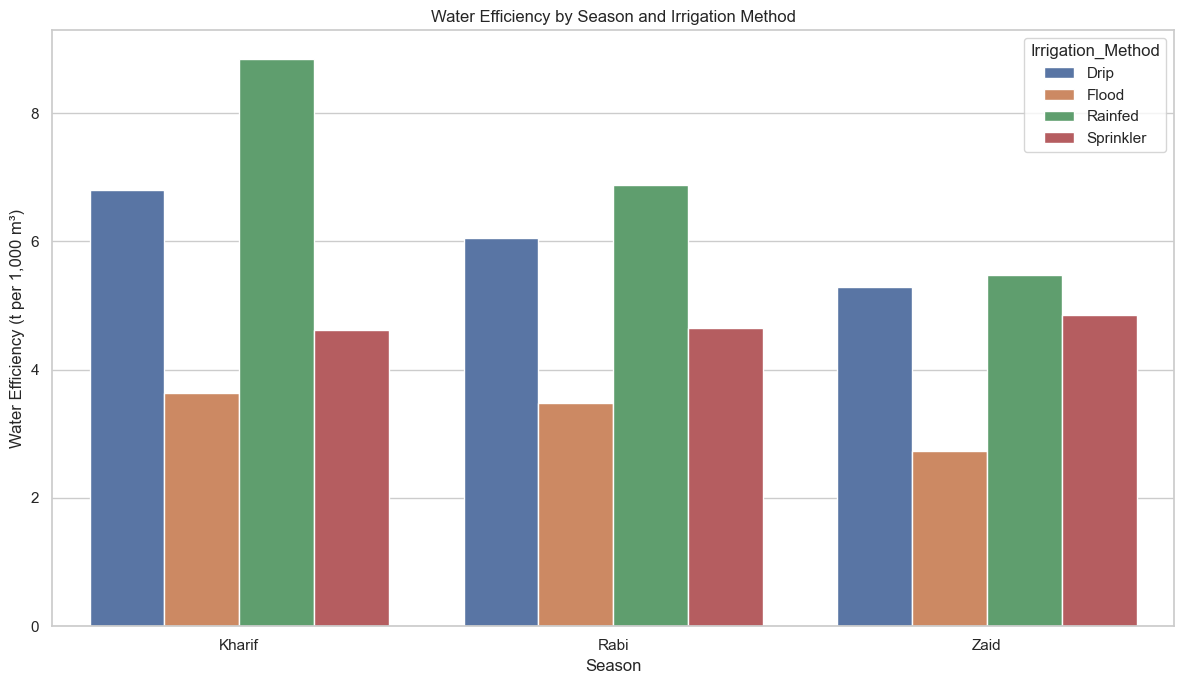

In [29]:
plt.figure(figsize=(12, 7))
sns.barplot(
    data=irrigation_perf,
    x="Season", y="Avg_Water_Efficiency",
    hue="Irrigation_Method",
    order=SEASON_ORDER
)
plt.title("Water Efficiency by Season and Irrigation Method")
plt.xlabel("Season")
plt.ylabel("Water Efficiency (t per 1,000 m³)")
plt.tight_layout()
plt.show()


In [30]:
def one_way_anova(df_in, column):
    groups = [
        df_in.loc[df_in["Season"] == season, column].dropna()
        for season in SEASON_ORDER
    ]
    return stats.f_oneway(*groups)

anova_rows = []
for col in [
    "Yield_Tonnes_Ha",
    "Profit_INR",
    "Water_Efficiency_t_per_1000m3",
    "Disease_Pest_Risk_pct"
]:
    f_stat, p_value = one_way_anova(df_clean, col)
    anova_rows.append({
        "Metric": col,
        "F_statistic": f_stat,
        "p_value": p_value,
        "Significant_at_0.05": p_value < 0.05
    })

anova_results = pd.DataFrame(anova_rows)
display(anova_results.round(5))


,Metric,F_statistic,p_value,Significant_at_0.05
0,Yield_Tonnes_Ha,1.46,0.23,False
1,Profit_INR,34.29,0.00,True
2,Water_Efficiency_t_per_1000m3,6.95,0.00,True
3,Disease_Pest_Risk_pct,"1,049.47",0.00,True


In [31]:
# Bonferroni-corrected pairwise Welch t-tests
pairwise_rows = []

for metric in [
    "Yield_Tonnes_Ha",
    "Profit_INR",
    "Water_Efficiency_t_per_1000m3",
    "Disease_Pest_Risk_pct"
]:
    for s1, s2 in combinations(SEASON_ORDER, 2):
        g1 = df_clean.loc[df_clean["Season"] == s1, metric].dropna()
        g2 = df_clean.loc[df_clean["Season"] == s2, metric].dropna()

        t_stat, p_raw = stats.ttest_ind(g1, g2, equal_var=False)
        p_adj = min(p_raw * 3, 1.0)

        pairwise_rows.append({
            "Metric": metric,
            "Comparison": f"{s1} vs {s2}",
            "t_statistic": t_stat,
            "p_raw": p_raw,
            "p_bonferroni": p_adj,
            "Significant_at_0.05": p_adj < 0.05
        })

pairwise_results = pd.DataFrame(pairwise_rows)
display(pairwise_results.round(5))


,Metric,Comparison,t_statistic,p_raw,p_bonferroni,Significant_at_0.05
0,Yield_Tonnes_Ha,Kharif vs Rabi,1.20,0.23,0.69,False
1,Yield_Tonnes_Ha,Kharif vs Zaid,1.69,0.09,0.27,False
2,Yield_Tonnes_Ha,Rabi vs Zaid,0.73,0.46,1.00,False
3,Profit_INR,Kharif vs Rabi,4.82,0.00,0.00,True
4,Profit_INR,Kharif vs Zaid,8.84,0.00,0.00,True
5,Profit_INR,Rabi vs Zaid,5.20,0.00,0.00,True
6,Water_Efficiency_t_per_1000m3,Kharif vs Rabi,2.27,0.02,0.07,False
7,Water_Efficiency_t_per_1000m3,Kharif vs Zaid,4.02,0.00,0.00,True
8,Water_Efficiency_t_per_1000m3,Rabi vs Zaid,2.21,0.03,0.08,False
9,Disease_Pest_Risk_pct,Kharif vs Rabi,40.38,0.00,0.00,True


In [33]:
# ============================================================
# Robust Two-Way ANOVA
# ============================================================

model_df = df_clean.dropna(subset=["Yield_Tonnes_Ha"]).copy()

# Convert Pandas StringDtype to ordinary Python object/string values
model_df["Season"] = model_df["Season"].astype(str)
model_df["Crop"] = model_df["Crop"].astype(str)

# Remove any accidental missing/invalid categorical values
model_df = model_df.dropna(subset=["Season", "Crop"])

# ------------------------------------------------------------
# Yield Model
# ------------------------------------------------------------

yield_model = ols(
    "Yield_Tonnes_Ha ~ C(Season) + C(Crop) + C(Season):C(Crop)",
    data=model_df
).fit()

yield_anova = anova_lm(yield_model, typ=2)

print("Two-way ANOVA: Yield ~ Season + Crop + Season × Crop")
display(yield_anova.round(5))


# ------------------------------------------------------------
# Profit Model
# ------------------------------------------------------------

profit_model = ols(
    "Profit_INR ~ C(Season) + C(Crop) + C(Season):C(Crop)",
    data=model_df
).fit()

profit_anova = anova_lm(profit_model, typ=2)

print("\nTwo-way ANOVA: Profit ~ Season + Crop + Season × Crop")
display(profit_anova.round(5))


Two-way ANOVA: Yield ~ Season + Crop + Season × Crop


,sum_sq,df,F,PR(>F)
C(Season),"1,546.91",2.00,24.04,0.00
C(Crop),"572,068.81",7.00,"2,540.57",0.00
C(Season):C(Crop),"8,757.80",14.00,19.45,0.00
Residual,"126,869.34","3,944.00",NaN,NaN



Two-way ANOVA: Profit ~ Season + Crop + Season × Crop


,sum_sq,df,F,PR(>F)
C(Season),"24,208,077,189,780.99",2.00,65.14,0.00
C(Crop),"416,471,993,243,160.06",7.00,320.17,0.00
C(Season):C(Crop),"11,869,528,347,716.67",14.00,4.56,0.00
Residual,"732,904,471,617,231.50","3,944.00",NaN,NaN


In [34]:
def iqr_outlier_summary(data, col):
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (data[col] < lower) | (data[col] > upper)
    return {
        "Metric": col,
        "Q1": q1,
        "Q3": q3,
        "Lower_Bound": lower,
        "Upper_Bound": upper,
        "Outlier_Count": int(mask.sum()),
        "Outlier_%": mask.mean() * 100
    }

outlier_report = pd.DataFrame([
    iqr_outlier_summary(df_clean, col)
    for col in [
        "Yield_Tonnes_Ha",
        "Profit_INR",
        "Water_Efficiency_t_per_1000m3"
    ]
])

display(outlier_report.round(2))


,Metric,Q1,Q3,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_%
0,Yield_Tonnes_Ha,1.05,2.84,-1.63,5.52,302,7.55
1,Profit_INR,"-148,731.75","216,187.75","-696,111.00","763,567.00",404,10.10
2,Water_Efficiency_t_per_1000m3,1.66,5.15,-3.57,10.38,322,8.05


In [35]:
def iqr_outlier_summary(data, col):
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (data[col] < lower) | (data[col] > upper)
    return {
        "Metric": col,
        "Q1": q1,
        "Q3": q3,
        "Lower_Bound": lower,
        "Upper_Bound": upper,
        "Outlier_Count": int(mask.sum()),
        "Outlier_%": mask.mean() * 100
    }

outlier_report = pd.DataFrame([
    iqr_outlier_summary(df_clean, col)
    for col in [
        "Yield_Tonnes_Ha",
        "Profit_INR",
        "Water_Efficiency_t_per_1000m3"
    ]
])

display(outlier_report.round(2))


,Metric,Q1,Q3,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_%
0,Yield_Tonnes_Ha,1.05,2.84,-1.63,5.52,302,7.55
1,Profit_INR,"-148,731.75","216,187.75","-696,111.00","763,567.00",404,10.10
2,Water_Efficiency_t_per_1000m3,1.66,5.15,-3.57,10.38,322,8.05


In [36]:
# Automated evidence table for the final discussion

evidence = pd.DataFrame({
    "Measure": [
        "Average Yield",
        "Average Profit",
        "Average Water Efficiency",
        "Average Disease/Pest Risk",
        "Loss-Making Farm Rate"
    ],
    "Kharif": [
        season_summary.loc["Kharif", "Avg_Yield"],
        season_summary.loc["Kharif", "Avg_Profit"],
        season_summary.loc["Kharif", "Avg_Water_Efficiency"],
        season_summary.loc["Kharif", "Avg_Risk"],
        season_summary.loc["Kharif", "Loss_Rate"]
    ],
    "Rabi": [
        season_summary.loc["Rabi", "Avg_Yield"],
        season_summary.loc["Rabi", "Avg_Profit"],
        season_summary.loc["Rabi", "Avg_Water_Efficiency"],
        season_summary.loc["Rabi", "Avg_Risk"],
        season_summary.loc["Rabi", "Loss_Rate"]
    ],
    "Zaid": [
        season_summary.loc["Zaid", "Avg_Yield"],
        season_summary.loc["Zaid", "Avg_Profit"],
        season_summary.loc["Zaid", "Avg_Water_Efficiency"],
        season_summary.loc["Zaid", "Avg_Risk"],
        season_summary.loc["Zaid", "Loss_Rate"]
    ]
})

display(evidence.round(2))

print("\nSuggested evidence-based findings:")
for season in SEASON_ORDER:
    print(
        f"{season}: avg yield={season_summary.loc[season,'Avg_Yield']:.2f} t/ha, "
        f"avg profit=₹{season_summary.loc[season,'Avg_Profit']:,.0f}, "
        f"loss rate={season_summary.loc[season,'Loss_Rate']:.1f}%."
    )

,Measure,Kharif,Rabi,Zaid
0,Average Yield,5.64,5.08,4.67
1,Average Profit,"178,914.65","87,689.47","-24,804.82"
2,Average Water Efficiency,5.89,5.19,4.41
3,Average Disease/Pest Risk,54.47,40.48,38.22
4,Loss-Making Farm Rate,42.21,51.14,64.48



Suggested evidence-based findings:
Kharif: avg yield=5.64 t/ha, avg profit=₹178,915, loss rate=42.2%.
Rabi: avg yield=5.08 t/ha, avg profit=₹87,689, loss rate=51.1%.
Zaid: avg yield=4.67 t/ha, avg profit=₹-24,805, loss rate=64.5%.


## Key Findings

1. **Seasonal performance differs across multiple dimensions.** Yield, profit, water efficiency and disease/pest risk should be evaluated together rather than using yield alone.

2. **Economic performance is especially important.** A season with lower average yield can still be preferable if its production costs, market prices and resource requirements produce better profitability.

3. **Crop composition strongly affects pooled yield comparisons.** The Crop × Season analysis demonstrates why seasonal yield averages should not be interpreted without considering crop mix.

4. **Regional patterns are not uniform.** State × Season results can reveal states where the strongest or weakest season differs from the overall national pattern.

5. **Water efficiency adds an important sustainability dimension.** Production planning should consider output relative to water consumption, not only absolute production.

6. **Disease/pest risk is seasonal.** Observed differences in risk support season-specific monitoring and preparedness.

7. **Environmental correlations are associations.** Rainfall, temperature, humidity and soil variables can help explain patterns, but correlation alone cannot establish causal effects.

8. **Statistical testing strengthens the analysis.** ANOVA and corrected pairwise comparisons distinguish observed differences from differences that are statistically supported.


# 17. Data-Driven Recommendations

1. **Use Crop × Season planning instead of a single seasonal strategy.** Crop-specific performance differs substantially, so recommendations should be tailored to the crop.

2. **Evaluate Zaid cultivation selectively.** Where profitability and loss rates are weaker, assess crop choice, input costs, water requirements and expected market returns before expanding cultivation.

3. **Prioritize water-efficiency improvements.** Compare irrigation methods within relevant crop and regional groups before scaling a water-management practice.

4. **Use region-specific seasonal strategies.** State-level variation means a strategy that works well in one state should not automatically be applied elsewhere.

5. **Strengthen seasonal disease/pest preparedness.** Allocate monitoring and preventive resources according to observed seasonal and regional risk.

6. **Balance productivity with profitability.** Yield targets should be evaluated together with cost, market price, revenue, profit and profit margin.

7. **Use environmental variables as supporting indicators.** Rainfall, temperature, humidity and soil moisture should be considered together with crop, resource and economic variables.

8. **Validate high-impact decisions with controlled analysis.** Where possible, use Crop, State, irrigation and input variables as controls before making operational or policy decisions.
